Import thư viện, tải dữ liệu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/ai_student_impact_dataset (1).csv')

Tổng quan dữ liệu

In [3]:
print(df.shape)
print(df.info())
print(df.describe(include='all').T)

missing = df.isnull().sum()
print(missing[missing > 0]) 

print("Số dòng trùng lặp:", df.duplicated().sum())
print("Trùng theo Student_ID:", df.duplicated(subset='Student_ID').sum())

(50000, 16)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50

Chia các cột input, output
input gồm 
- Weekly_GenAI_Hours: float
- Tool_Diversity: interger
- Paid_Subscription: boolea n, đổi về int 0/1
- Pre_Semester_GPA : float
- Perceived_AI_Dependency: int
Đổi kiểu dữ liệu của Paid_Supscription sang int (1/0)

In [4]:
df['Paid_Subscription'] = df['Paid_Subscription'].astype(int)

features = ['Perceived_AI_Dependency', 'Weekly_GenAI_Hours', 'Tool_Diversity',
            'Paid_Subscription', 'Pre_Semester_GPA']
target = 'Post_Semester_GPA'

for col in features:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, n_unique={df[col].nunique()}")


Perceived_AI_Dependency: min=1, max=10, n_unique=10
Weekly_GenAI_Hours: min=0.0, max=40.0, n_unique=3566
Tool_Diversity: min=1, max=5, n_unique=5
Paid_Subscription: min=0, max=1, n_unique=2
Pre_Semester_GPA: min=1.183, max=3.998, n_unique=2389


THÔNG SỐ OUTLIER CỦA WEEKLY_GENAI_HOURS
Q1 (25%): 2.39 giờ | Q3 (75%): 11.72 giờ
Khoảng IQR: 9.33 giờ
Ngưỡng outlier trên (Upper Bound): 25.72 giờ/tuần
Số lượng Outliers: 2583 dòng (5.17% trên tổng số dữ liệu)



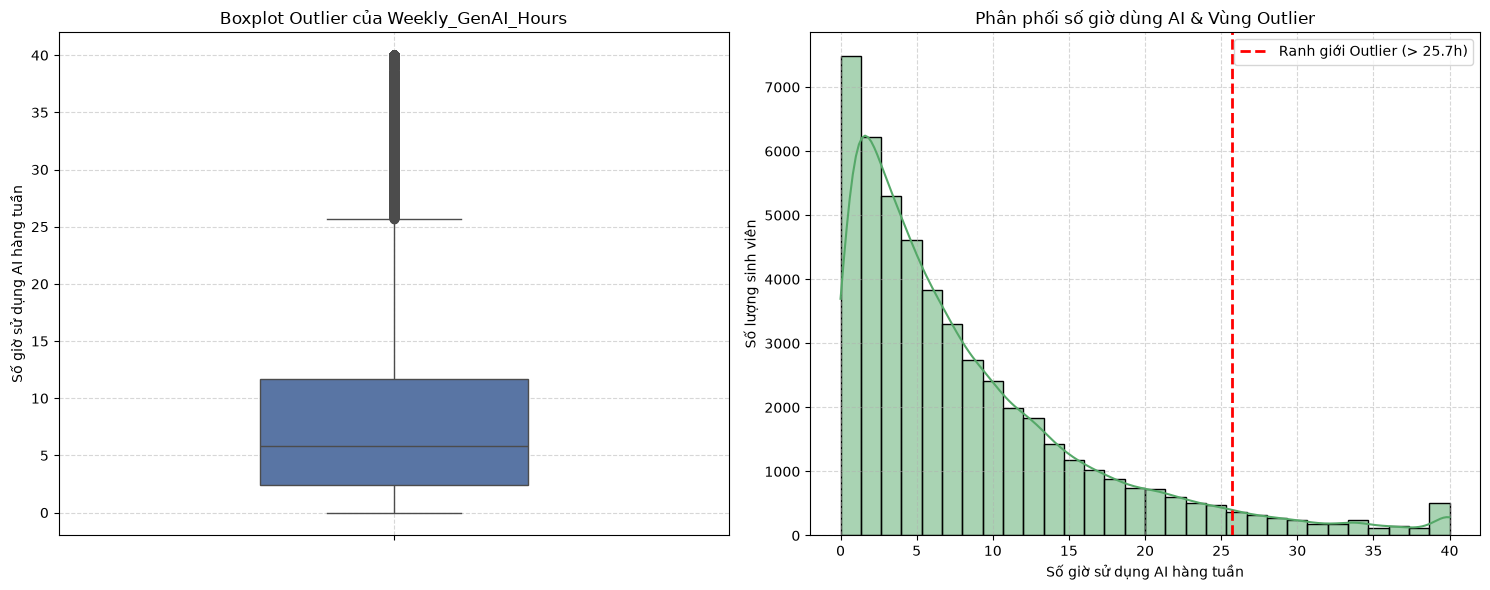

In [5]:
Q1, Q3 = df['Weekly_GenAI_Hours'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Weekly_GenAI_Hours'] < lower_bound) | (df['Weekly_GenAI_Hours'] > upper_bound)]

print(f"THÔNG SỐ OUTLIER CỦA WEEKLY_GENAI_HOURS")
print(f"Q1 (25%): {Q1:.2f} giờ | Q3 (75%): {Q3:.2f} giờ")
print(f"Khoảng IQR: {IQR:.2f} giờ")
print(f"Ngưỡng outlier trên (Upper Bound): {upper_bound:.2f} giờ/tuần")
print(f"Số lượng Outliers: {len(outliers)} dòng ({len(outliers)/len(df)*100:.2f}% trên tổng số dữ liệu)\n")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(y=df['Weekly_GenAI_Hours'], ax=axes[0], color='#4C72B0', width=0.4)
axes[0].set_title('Boxplot Outlier của Weekly_GenAI_Hours', fontsize=12)
axes[0].set_ylabel('Số giờ sử dụng AI hàng tuần', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(df['Weekly_GenAI_Hours'], kde=True, ax=axes[1], color='#55A868', bins=30)
axes[1].axvline(upper_bound, color='red', linestyle='--', linewidth=2, 
                label=f'Ranh giới Outlier (> {upper_bound:.1f}h)')
axes[1].set_title('Phân phối số giờ dùng AI & Vùng Outlier', fontsize=12)
axes[1].set_xlabel('Số giờ sử dụng AI hàng tuần', fontsize=10)
axes[1].set_ylabel('Số lượng sinh viên', fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Phân phối input

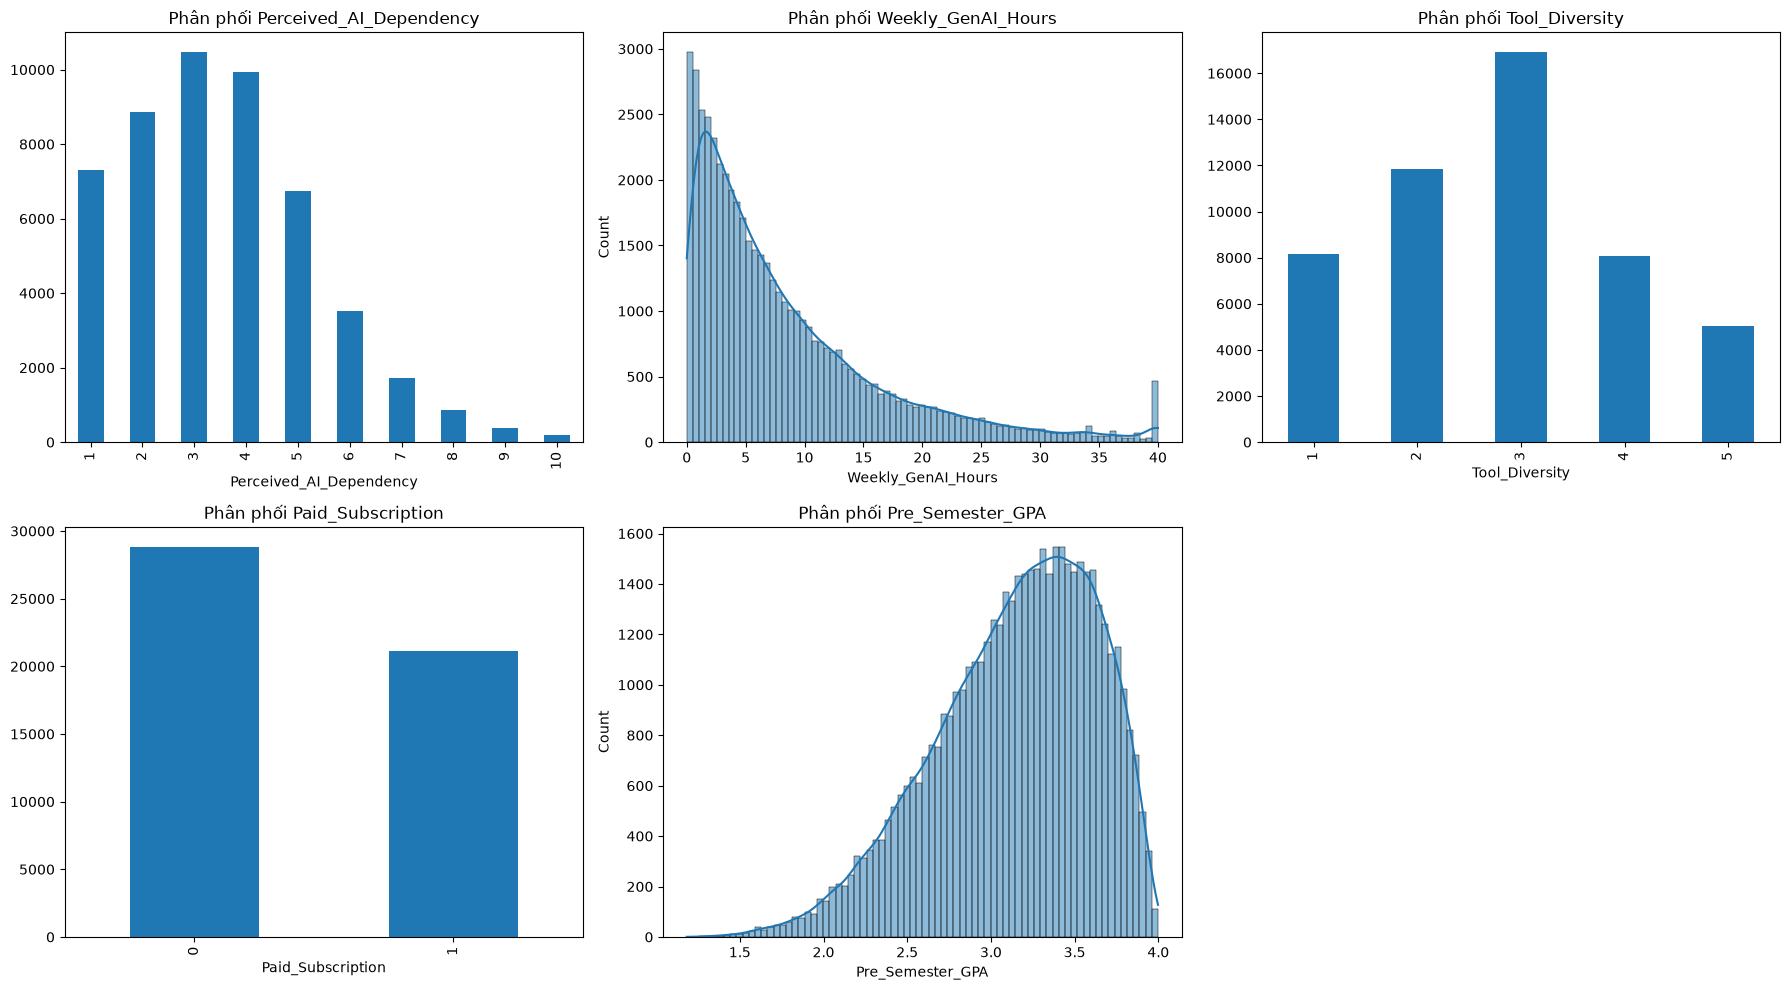

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), features):
    if df[col].nunique() <= 10:
        df[col].value_counts().sort_index().plot(kind='bar', ax=ax)
    else:
        sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Phân phối {col}')
axes[-1, -1].axis('off')
plt.tight_layout()
plt.show()

Phân phối output

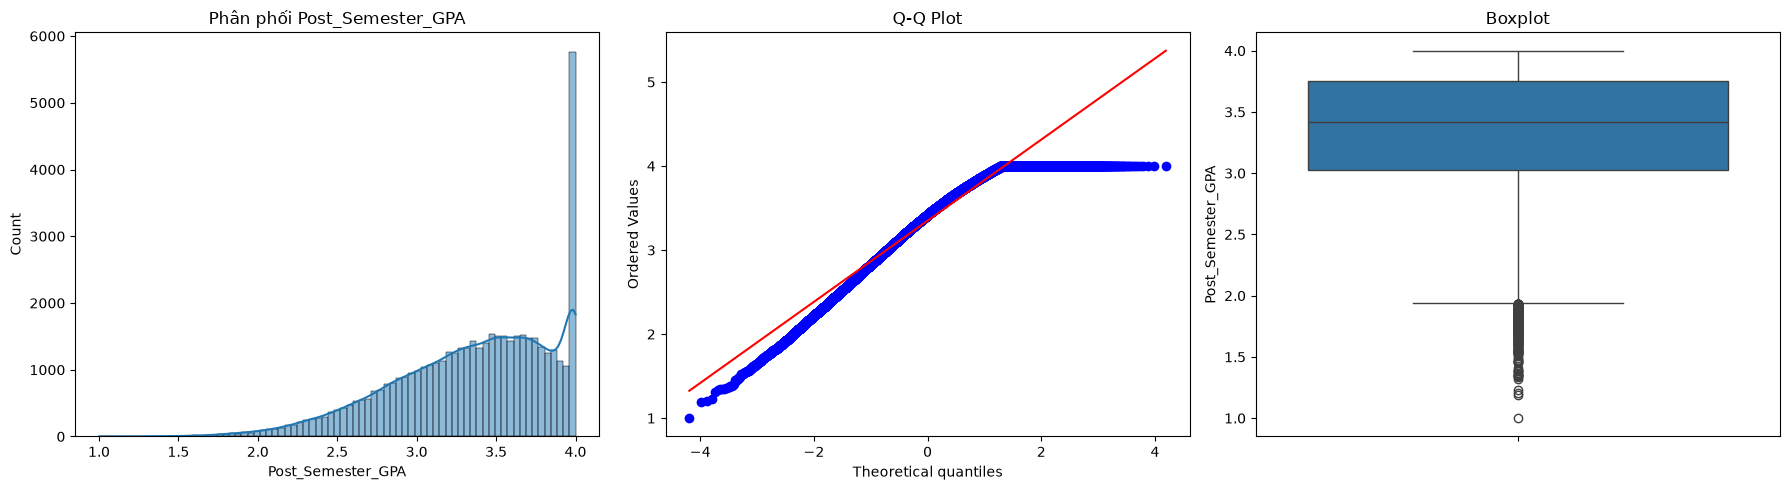

Skewness: -0.6750590054046929
ShapiroResult(statistic=np.float64(0.9498222075444132), pvalue=np.float64(2.584238990514052e-38))


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
sns.histplot(df['Post_Semester_GPA'], kde=True, ax=axes[0])
axes[0].set_title('Phân phối Post_Semester_GPA')

# Q-Q plot 
from scipy import stats
stats.probplot(df['Post_Semester_GPA'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

# Boxplot
sns.boxplot(y=df['Post_Semester_GPA'], ax=axes[2])
axes[2].set_title('Boxplot')
plt.tight_layout()
plt.show()

print("Skewness:", df['Post_Semester_GPA'].skew())
print(stats.shapiro(df['Post_Semester_GPA'].sample(min(5000, len(df)))))

Tương quan giữa các features

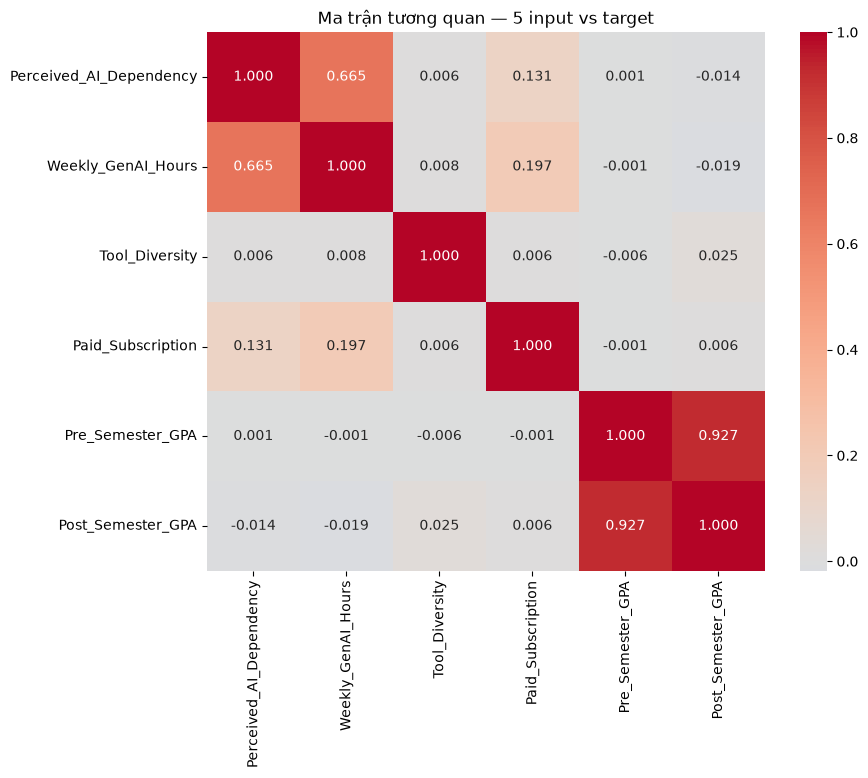

In [12]:
corr = df[features + [target]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Ma trận tương quan — 5 input vs target')
plt.show()

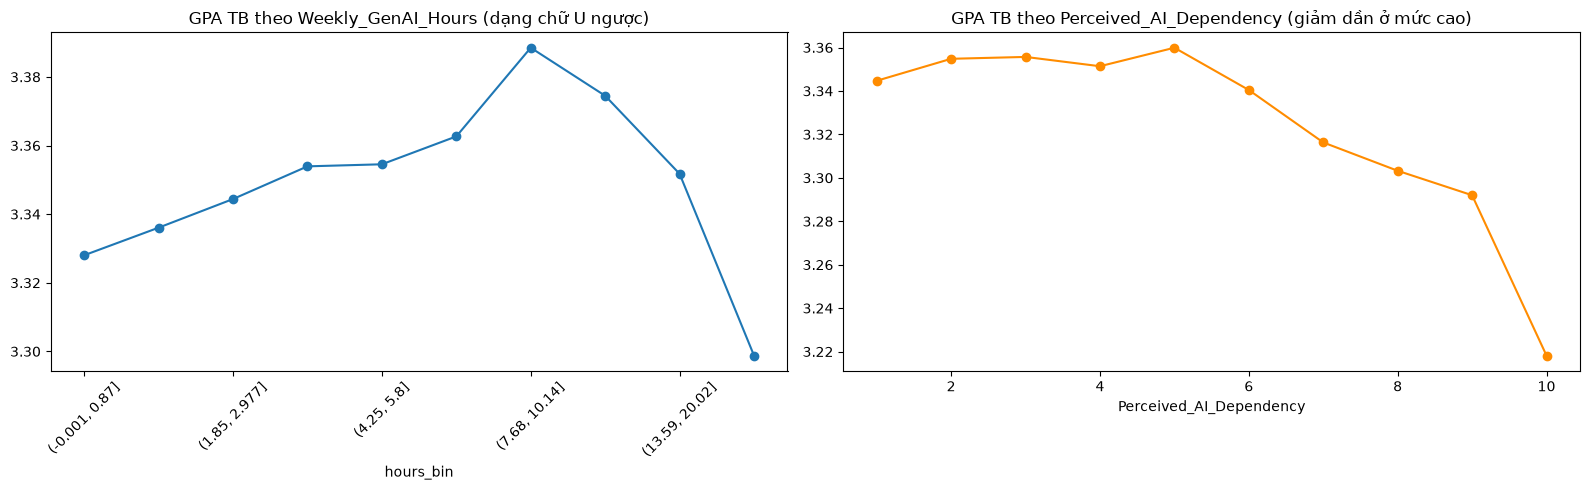

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Weekly_GenAI_Hours
df['hours_bin'] = pd.qcut(df['Weekly_GenAI_Hours'], 10, duplicates='drop')
df.groupby('hours_bin', observed=True)[target].mean().plot(marker='o', ax=axes[0])
axes[0].set_title('GPA TB theo Weekly_GenAI_Hours')
axes[0].tick_params(axis='x', rotation=45)

# Perceived_AI_Dependency 
df.groupby('Perceived_AI_Dependency')[target].mean().plot(marker='o', color='darkorange', ax=axes[1])
axes[1].set_title('GPA TB theo Perceived_AI_Dependency')
plt.tight_layout()
plt.show()

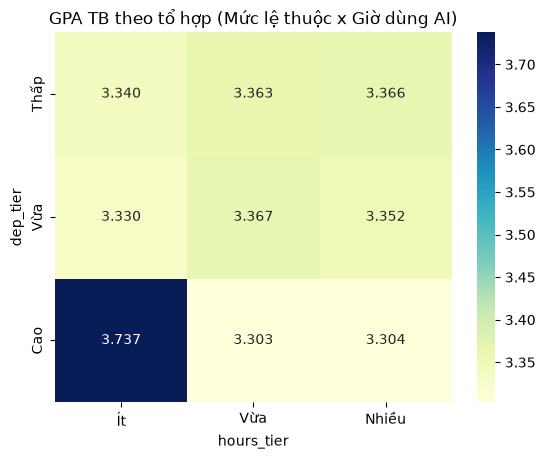

hours_tier        Ít       Vừa     Nhiều
dep_tier                                
Thấp        3.339702  3.362615  3.366429
Vừa         3.329790  3.366756  3.352041
Cao         3.737500  3.303232  3.303635


In [15]:
df['dep_tier'] = pd.cut(df['Perceived_AI_Dependency'], bins=[0,3,6,10], labels=['Thấp','Vừa','Cao'])
df['hours_tier'] = pd.qcut(df['Weekly_GenAI_Hours'], 3, labels=['Ít','Vừa','Nhiều'])

pivot = df.pivot_table(index='dep_tier', columns='hours_tier', values=target, observed=True)
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('GPA TB theo tổ hợp (Mức lệ thuộc x Giờ dùng AI)')
plt.show()
print(pivot)